In [3]:
from __future__ import annotations

import gc
import json
import os
import sys
from collections.abc import Mapping
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch

def canonical_id(value) -> str:
    """Normalize sample IDs so values such as 123 and 123.0 match."""
    if value is None:
        return "<missing>"

    try:
        if pd.isna(value):
            return "<missing>"
    except (TypeError, ValueError):
        pass

    text = str(value).strip()

    try:
        number = float(text)

        if (
            np.isfinite(number)
            and number.is_integer()
        ):
            return str(int(number))

    except (TypeError, ValueError):
        pass

    return text


# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

THESIS_DIR = Path(
    "/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS"
)

THIRD_PARTY_DIR = (
    THESIS_DIR
    / "third_party"
    / "dl_fault_repo"
)

CONFIG_DIR = (
    THIRD_PARTY_DIR
    / "config"
)

WINDOWS_DIR = Path(
    "/home/vault/iwi5/iwi5305h/windows_tmp"
)

SOURCE_RUN_ROOT = (
    THESIS_DIR
    / "outputs"
    / "chapter4"
    / "temp_90kv_afs_check"
    / "hybrid_runs"
    / "1764759_20260729_150855"
)

AFS_INPUT_DIR = (
    THESIS_DIR
    / "outputs"
    / "chapter4"
    / "temp_90kv_afs_check"
    / "model_inputs"
    / "20260729_122907"
)

ONE_ENDED_PRIOR = (
    AFS_INPUT_DIR
    / "kol_operator_features_hv_double_line_90kv_"
      "case_bestmae_all_fault_start_model_input.csv"
)

TWO_ENDED_PRIOR = (
    AFS_INPUT_DIR
    / "kol_operator_features_hv_double_line_90kv_"
      "two_ended_posseq_all_fault_start_model_input.csv"
)

ROW_AUDIT = (
    AFS_INPUT_DIR
    / "temporary_prior_row_audit.csv"
)

LAUNCHER = (
    THESIS_DIR
    / "recover_90kv_afs_eval_launcher.py"
)

ANALYSIS_SCRIPT = (
    THESIS_DIR
    / "analyse_90kv_afs_recovery.py"
)


EXPERIMENTS = {
    "C90-1E-AFS-TMP": {
        "prior": ONE_ENDED_PRIOR,
        "feature_cols": [
            "ratio_V0_V1",
            "ratio_V2_V1",
            "ratio_I0_I1",
            "ratio_I2_I1",
            "abs_Z0_app",
            "abs_Z2_app",
        ],
        "model_mode": "legacy_residual",
        "hidden_size": 384,
        "num_layers": 3,
        "dropout": 0.2,
    },
    "L90-1E-AFS-TMP": {
        "prior": ONE_ENDED_PRIOR,
        "feature_cols": [
            "ratio_V0_V1",
            "ratio_V2_V1",
            "ratio_I0_I1",
            "ratio_I2_I1",
            "abs_Z0_app",
            "abs_Z2_app",
        ],
        "model_mode": "bounded_residual_fusion",
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.0,
    },
    "C90-2E-AFS-TMP": {
        "prior": TWO_ENDED_PRIOR,
        "feature_cols": [],
        "model_mode": "legacy_residual",
        "hidden_size": 384,
        "num_layers": 3,
        "dropout": 0.2,
    },
    "L90-2E-AFS-TMP": {
        "prior": TWO_ENDED_PRIOR,
        "feature_cols": [],
        "model_mode": "bounded_residual_fusion",
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.0,
    },
}


# ---------------------------------------------------------------------
# General path checks
# ---------------------------------------------------------------------

required_paths = [
    THESIS_DIR,
    THIRD_PARTY_DIR,
    CONFIG_DIR,
    CONFIG_DIR / "main-config.yaml",
    WINDOWS_DIR,
    SOURCE_RUN_ROOT,
    AFS_INPUT_DIR,
    ONE_ENDED_PRIOR,
    TWO_ENDED_PRIOR,
    ROW_AUDIT,
    LAUNCHER,
    ANALYSIS_SCRIPT,
]

missing_paths = [
    str(path)
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required paths:\n"
        + "\n".join(missing_paths)
    )

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Recovery device: CPU")


# ---------------------------------------------------------------------
# Available memory
# ---------------------------------------------------------------------

try:
    import psutil

    memory = psutil.virtual_memory()

    print(
        "Total RAM:",
        f"{memory.total / 1024**3:.1f} GiB",
    )

    print(
        "Available RAM:",
        f"{memory.available / 1024**3:.1f} GiB",
    )

    if memory.available < 45 * 1024**3:
        print(
            "WARNING: less than 45 GiB RAM is currently available."
        )

except ImportError:
    print(
        "psutil is unavailable; RAM could not be checked."
    )


# ---------------------------------------------------------------------
# Waveform cohort checks
# ---------------------------------------------------------------------

waveform_pattern = (
    "*hv_double_line_90kv_W0p060_S0p005*"
)

waveform_files = sorted(
    WINDOWS_DIR.glob(waveform_pattern)
)

raw_file = (
    WINDOWS_DIR
    / "X_hv_double_line_90kv_W0p060_S0p005.raw"
)

print("\nWaveform files found:", len(waveform_files))
print("Raw waveform exists:", raw_file.exists())

if not waveform_files:
    raise FileNotFoundError(
        f"No files matched {waveform_pattern}"
    )

if not raw_file.exists():
    raise FileNotFoundError(raw_file)


# ---------------------------------------------------------------------
# Prior-column checks
# ---------------------------------------------------------------------

prior_audit_rows = []

prior_specifications = [
    {
        "prior_name": "one_ended",
        "path": ONE_ENDED_PRIOR,
        "required_columns": [
            "sample_id",
            "window_idx",
            "d_phys_real_pct",
            "ratio_V0_V1",
            "ratio_V2_V1",
            "ratio_I0_I1",
            "ratio_I2_I1",
            "abs_Z0_app",
            "abs_Z2_app",
        ],
    },
    {
        "prior_name": "two_ended",
        "path": TWO_ENDED_PRIOR,
        "required_columns": [
            "sample_id",
            "window_idx",
            "d_phys_real_pct",
        ],
    },
]

for specification in prior_specifications:
    prior_name = specification["prior_name"]
    prior_path = specification["path"]
    required_columns = specification["required_columns"]

    # Read the full key and prior columns so we can also verify uniqueness,
    # row count, finite values, and window coverage.
    frame = pd.read_csv(prior_path)

    missing_columns = sorted(
        set(required_columns)
        - set(frame.columns)
    )

    duplicate_key_count = (
        int(
            frame.duplicated(
                [
                    "sample_id",
                    "window_idx",
                ]
            ).sum()
        )
        if {
            "sample_id",
            "window_idx",
        }.issubset(frame.columns)
        else None
    )

    prior_values = (
        pd.to_numeric(
            frame["d_phys_real_pct"],
            errors="coerce",
        )
        if "d_phys_real_pct" in frame.columns
        else pd.Series(dtype=float)
    )

    finite_prior_count = int(
        np.isfinite(prior_values).sum()
    )

    window_indices = (
        sorted(
            pd.to_numeric(
                frame["window_idx"],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        )
        if "window_idx" in frame.columns
        else []
    )

    row_count_ok = len(frame) == 40564

    event_count = (
        frame["sample_id"]
        .map(canonical_id)
        .nunique()
        if "sample_id" in frame.columns
        else 0
    )

    event_count_ok = event_count == 9022

    finite_ok = (
        finite_prior_count
        == len(frame)
    )

    duplicate_ok = (
        duplicate_key_count == 0
    )

    windows_ok = (
        set(window_indices)
        == {
            8,
            9,
            10,
            11,
            12,
        }
    )

    status = (
        "PASS"
        if (
            not missing_columns
            and row_count_ok
            and event_count_ok
            and finite_ok
            and duplicate_ok
            and windows_ok
        )
        else "FAIL"
    )

    prior_audit_rows.append(
        {
            "prior": prior_name,
            "path": str(prior_path),
            "rows": len(frame),
            "events": event_count,
            "column_count": len(frame.columns),
            "missing_columns": missing_columns,
            "duplicate_key_count": duplicate_key_count,
            "finite_prior_count": finite_prior_count,
            "window_indices": window_indices,
            "status": status,
        }
    )


prior_audit = pd.DataFrame(
    prior_audit_rows
)

display(prior_audit)

if (
    prior_audit["status"]
    != "PASS"
).any():
    raise RuntimeError(
        "At least one prior CSV failed its structural checks."
    )


# ---------------------------------------------------------------------
# Checkpoint-schema detection
# ---------------------------------------------------------------------

def looks_like_state_dict(
    value,
) -> bool:
    if not isinstance(value, Mapping):
        return False

    if not value:
        return False

    values = list(value.values())

    tensor_count = sum(
        torch.is_tensor(item)
        or isinstance(item, torch.nn.Parameter)
        for item in values
    )

    return tensor_count >= max(
        1,
        int(0.8 * len(values)),
    )


def find_state_dict(
    value,
    path: str = "root",
    depth: int = 0,
):
    if isinstance(value, torch.nn.Module):
        return value.state_dict(), path + ".state_dict()"

    if looks_like_state_dict(value):
        return value, path

    if (
        isinstance(value, Mapping)
        and depth < 5
    ):
        preferred_keys = [
            "model_state_dict",
            "state_dict",
            "model",
            "model_state",
            "network",
            "net",
            "weights",
            "model_weights",
            "checkpoint",
        ]

        visited = set()

        for key in preferred_keys:
            if key in value:
                visited.add(key)

                result = find_state_dict(
                    value[key],
                    path=f"{path}.{key}",
                    depth=depth + 1,
                )

                if result is not None:
                    return result

        for key, nested in value.items():
            if key in visited:
                continue

            if isinstance(
                nested,
                (
                    Mapping,
                    torch.nn.Module,
                ),
            ):
                result = find_state_dict(
                    nested,
                    path=f"{path}.{key}",
                    depth=depth + 1,
                )

                if result is not None:
                    return result

    return None


def find_source_run_dir(
    experiment_dir: Path,
) -> Path:
    candidates = sorted(
        [
            path
            for path in experiment_dir.iterdir()
            if (
                path.is_dir()
                and "__run_" in path.name
                and (path / "splits").is_dir()
            )
        ],
        key=lambda path: path.stat().st_mtime,
    )

    if not candidates:
        raise FileNotFoundError(
            f"No source run directory under {experiment_dir}"
        )

    return candidates[-1]


checkpoint_rows = []

for experiment in EXPERIMENTS:
    experiment_dir = (
        SOURCE_RUN_ROOT
        / experiment
    )

    checkpoint_dir = (
        experiment_dir
        / "checkpoints"
    )

    checkpoints = sorted(
        checkpoint_dir.glob(
            "*fold*seed42.pt"
        )
    )

    source_run_dir = find_source_run_dir(
        experiment_dir
    )

    split_files = sorted(
        (
            source_run_dir
            / "splits"
        ).glob(
            "fold*_splits.json"
        )
    )

    if len(checkpoints) != 5:
        raise RuntimeError(
            f"{experiment}: expected 5 checkpoints, "
            f"found {len(checkpoints)}"
        )

    if len(split_files) != 5:
        raise RuntimeError(
            f"{experiment}: expected 5 split files, "
            f"found {len(split_files)}"
        )

    for checkpoint_path in checkpoints:
        payload = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )

        result = find_state_dict(payload)

        if isinstance(payload, Mapping):
            top_level_keys = list(payload.keys())
        else:
            top_level_keys = []

        if result is None:
            state_path = None
            parameter_count = 0
            first_parameter = None
            status = "FAIL"

        else:
            state_dict, state_path = result

            parameter_count = len(state_dict)

            first_parameter = next(
                iter(state_dict.keys()),
                None,
            )

            status = "PASS"

        fold_match = __import__("re").search(
            r"fold(\d+)",
            checkpoint_path.name,
        )

        checkpoint_rows.append(
            {
                "experiment": experiment,
                "fold": (
                    int(fold_match.group(1))
                    if fold_match
                    else None
                ),
                "checkpoint": str(checkpoint_path),
                "payload_type": type(payload).__name__,
                "top_level_keys": top_level_keys,
                "detected_state_dict_path": state_path,
                "parameter_tensor_count": parameter_count,
                "first_parameter": first_parameter,
                "status": status,
            }
        )

        del payload
        gc.collect()


checkpoint_audit = pd.DataFrame(
    checkpoint_rows
).sort_values(
    [
        "experiment",
        "fold",
    ]
)

display(
    checkpoint_audit[
        [
            "experiment",
            "fold",
            "payload_type",
            "top_level_keys",
            "detected_state_dict_path",
            "parameter_tensor_count",
            "first_parameter",
            "status",
        ]
    ]
)

if (
    checkpoint_audit["status"]
    != "PASS"
).any():
    raise RuntimeError(
        "At least one checkpoint has no detectable model state dictionary."
    )


# ---------------------------------------------------------------------
# Split coverage checks
# ---------------------------------------------------------------------

split_audit_rows = []

for experiment in EXPERIMENTS:
    source_run_dir = find_source_run_dir(
        SOURCE_RUN_ROOT
        / experiment
    )

    test_group_owner = {}
    total_saved_test_rows = 0

    for split_path in sorted(
        (
            source_run_dir
            / "splits"
        ).glob(
            "fold*_splits.json"
        )
    ):
        payload = json.loads(
            split_path.read_text(
                encoding="utf-8"
            )
        )

        fold = int(payload["fold"])
        test_groups = {
            str(value)
            for value in payload["test_groups"]
        }

        total_saved_test_rows += int(
            payload["n_test"]
        )

        for group in test_groups:
            if group in test_group_owner:
                raise RuntimeError(
                    f"{experiment}: event {group} "
                    "appears in multiple test folds"
                )

            test_group_owner[group] = fold

    split_audit_rows.append(
        {
            "experiment": experiment,
            "test_rows": total_saved_test_rows,
            "test_events": len(test_group_owner),
            "expected_rows": 40564,
            "expected_events": 9022,
            "status": (
                "PASS"
                if (
                    total_saved_test_rows == 40564
                    and len(test_group_owner) == 9022
                )
                else "FAIL"
            ),
        }
    )


split_audit = pd.DataFrame(split_audit_rows)
display(split_audit)

if (
    split_audit["status"]
    != "PASS"
).any():
    raise RuntimeError(
        "Saved fold splits do not cover the expected cohort."
    )


print("\n====================================================")
print("PREFLIGHT PASSED")
print("====================================================")
print("All four experiments have:")
print("- required paths")
print("- required prior columns")
print("- five checkpoints")
print("- detectable model weights")
print("- five split files")
print("- 40,564 held-out window rows")
print("- 9,022 held-out events")

Python: /home/hpc/iwi5/iwi5305h/miniconda3/envs/Masters_thesis_env_py312/bin/python
PyTorch: 2.10.0+cu128
CUDA available: False
Recovery device: CPU
Total RAM: 502.8 GiB
Available RAM: 483.2 GiB

Waveform files found: 5
Raw waveform exists: True


,prior,path,rows,events,column_count,missing_columns,duplicate_key_count,finite_prior_count,window_indices,status
0,one_ended,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,40564,9022,10,[],0,40564,"[8, 9, 10, 11, 12]",PASS
1,two_ended,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,40564,9022,4,[],0,40564,"[8, 9, 10, 11, 12]",PASS


,experiment,fold,payload_type,top_level_keys,detected_state_dict_path,parameter_tensor_count,first_parameter,status
0,C90-1E-AFS-TMP,0,dict,"[state_dict, task_type, target_label, feature_...",root.state_dict,16,gru.weight_ih_l0,PASS
1,C90-1E-AFS-TMP,1,dict,"[state_dict, task_type, target_label, feature_...",root.state_dict,16,gru.weight_ih_l0,PASS
2,C90-1E-AFS-TMP,2,dict,"[state_dict, task_type, target_label, feature_...",root.state_dict,16,gru.weight_ih_l0,PASS
3,C90-1E-AFS-TMP,3,dict,"[state_dict, task_type, target_label, feature_...",root.state_dict,16,gru.weight_ih_l0,PASS
4,C90-1E-AFS-TMP,4,dict,"[state_dict, task_type, target_label, feature_...",root.state_dict,16,gru.weight_ih_l0,PASS
10,C90-2E-AFS-TMP,0,dict,"[state_dict, task_type, target_label, feature_...",root.state_dict,16,gru.weight_ih_l0,PASS
11,C90-2E-AFS-TMP,1,dict,"[state_dict, task_type, target_label, feature_...",root.state_dict,16,gru.weight_ih_l0,PASS
12,C90-2E-AFS-TMP,2,dict,"[state_dict, task_type, target_label, feature_...",root.state_dict,16,gru.weight_ih_l0,PASS
13,C90-2E-AFS-TMP,3,dict,"[state_dict, task_type, target_label, feature_...",root.state_dict,16,gru.weight_ih_l0,PASS
14,C90-2E-AFS-TMP,4,dict,"[state_dict, task_type, target_label, feature_...",root.state_dict,16,gru.weight_ih_l0,PASS


,experiment,test_rows,test_events,expected_rows,expected_events,status
0,C90-1E-AFS-TMP,40564,9022,40564,9022,PASS
1,L90-1E-AFS-TMP,40564,9022,40564,9022,PASS
2,C90-2E-AFS-TMP,40564,9022,40564,9022,PASS
3,L90-2E-AFS-TMP,40564,9022,40564,9022,PASS



PREFLIGHT PASSED
All four experiments have:
- required paths
- required prior columns
- five checkpoints
- detectable model weights
- five split files
- 40,564 held-out window rows
- 9,022 held-out events


In [4]:
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path


RUN_TIMESTAMP = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

RECOVERY_ROOT = (
    SOURCE_RUN_ROOT
    / "recovered_oof"
    / f"jupyter_{RUN_TIMESTAMP}"
)

ANALYSIS_DIR = (
    SOURCE_RUN_ROOT
    / "analysis_final"
    / f"jupyter_{RUN_TIMESTAMP}"
)

RECOVERY_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


DRIVER_CODE = r'''
from __future__ import annotations

import sys
from collections import OrderedDict
from collections.abc import Mapping

import torch


# Preserve the real PyTorch loader before any repository patching.
_REAL_TORCH_LOAD = torch.load
_REAL_LOAD_STATE_DICT = torch.nn.Module.load_state_dict


def _looks_like_state_dict(value):
    if not isinstance(value, Mapping) or not value:
        return False

    values = list(value.values())

    tensor_count = sum(
        torch.is_tensor(item)
        or isinstance(item, torch.nn.Parameter)
        for item in values
    )

    return tensor_count >= max(
        1,
        int(0.8 * len(values)),
    )


def _find_state_dict(
    value,
    path="root",
    depth=0,
):
    if isinstance(value, torch.nn.Module):
        return value.state_dict(), path + ".state_dict()"

    if _looks_like_state_dict(value):
        return value, path

    if isinstance(value, Mapping) and depth < 5:
        preferred_keys = [
            "model_state_dict",
            "state_dict",
            "model",
            "model_state",
            "network",
            "net",
            "weights",
            "model_weights",
            "checkpoint",
        ]

        visited = set()

        for key in preferred_keys:
            if key in value:
                visited.add(key)

                result = _find_state_dict(
                    value[key],
                    path=f"{path}.{key}",
                    depth=depth + 1,
                )

                if result is not None:
                    return result

        for key, nested in value.items():
            if key in visited:
                continue

            if isinstance(
                nested,
                (
                    Mapping,
                    torch.nn.Module,
                ),
            ):
                result = _find_state_dict(
                    nested,
                    path=f"{path}.{key}",
                    depth=depth + 1,
                )

                if result is not None:
                    return result

    return None


def _compatible_torch_load(
    *args,
    **kwargs,
):
    kwargs.setdefault(
        "weights_only",
        False,
    )

    payload = _REAL_TORCH_LOAD(
        *args,
        **kwargs,
    )

    source = (
        str(args[0])
        if args
        else str(kwargs.get("f", ""))
    )

    # Do not alter unrelated torch.load calls.
    if (
        "checkpoints" not in source
        or not source.endswith(".pt")
    ):
        return payload

    if (
        isinstance(payload, Mapping)
        and "model_state_dict" in payload
    ):
        return payload

    result = _find_state_dict(payload)

    if result is None:
        raise RuntimeError(
            "Checkpoint contains no detectable model state dictionary: "
            f"{source}"
        )

    state_dict, state_path = result

    if (
        isinstance(payload, Mapping)
        and state_path != "root"
    ):
        normalized = dict(payload)

    else:
        normalized = {}

    normalized["model_state_dict"] = state_dict
    normalized.setdefault("meta", {})

    print(
        "CHECKPOINT NORMALIZED:",
        source,
        "| state path:",
        state_path,
        "| tensors:",
        len(state_dict),
        flush=True,
    )

    return normalized


def _call_original_load_state_dict(
    module,
    state_dict,
    strict,
    assign,
):
    try:
        return _REAL_LOAD_STATE_DICT(
            module,
            state_dict,
            strict=strict,
            assign=assign,
        )

    except TypeError:
        return _REAL_LOAD_STATE_DICT(
            module,
            state_dict,
            strict=strict,
        )


def _compatible_load_state_dict(
    module,
    state_dict,
    strict=True,
    assign=False,
):
    try:
        return _call_original_load_state_dict(
            module,
            state_dict,
            strict,
            assign,
        )

    except RuntimeError as original_error:
        keys = list(state_dict.keys())

        for prefix in [
            "module.",
            "model.",
            "network.",
            "net.",
        ]:
            if (
                keys
                and all(
                    key.startswith(prefix)
                    for key in keys
                )
            ):
                stripped = OrderedDict(
                    (
                        key[len(prefix):],
                        value,
                    )
                    for key, value
                    in state_dict.items()
                )

                try:
                    result = _call_original_load_state_dict(
                        module,
                        stripped,
                        strict,
                        assign,
                    )

                    print(
                        "STATE-DICT PREFIX REMOVED:",
                        prefix,
                        flush=True,
                    )

                    return result

                except RuntimeError:
                    pass

        raise original_error


torch.load = _compatible_torch_load
torch.nn.Module.load_state_dict = _compatible_load_state_dict


import recover_90kv_afs_eval_launcher as launcher

launcher.main()
'''


def hydra_feature_list(
    columns: list[str],
) -> str:
    return (
        "["
        + ",".join(columns)
        + "]"
    )


def run_recovery_experiment(
    experiment: str,
) -> None:
    config = EXPERIMENTS[experiment]

    source_experiment = (
        SOURCE_RUN_ROOT
        / experiment
    )

    checkpoint_dir = (
        source_experiment
        / "checkpoints"
    )

    recovery_output = (
        RECOVERY_ROOT
        / experiment
    )

    recovery_audit = (
        recovery_output
        / "recovery_audit"
    )

    recovery_output.mkdir(
        parents=True,
        exist_ok=True,
    )

    recovery_audit.mkdir(
        parents=True,
        exist_ok=True,
    )

    overrides = [
        "dataset=hv_double_line_90kv",

        "model.model_name=gru_regressor",
        f"model.hidden_size={config['hidden_size']}",
        f"model.num_layers={config['num_layers']}",
        f"model.dropout={config['dropout']}",
        "model.bidirectional=false",

        "training.target_label=y_fault_location",
        "training.feature_groups_include=[lines,loads,winds,extgrid]",

        "training.batch_size=64",
        "training.epochs=150",
        "training.patience=20",

        "training.tune_lr_wd=false",
        "training.learning_rate=0.0003",
        "training.weight_decay=0.0001",

        "training.seeds=[42]",
        "training.n_splits=5",
        "training.split_seed=42",

        f"training.ckpt_dir={checkpoint_dir}",
        f"+training.out_dir={recovery_output}",

        "+training.use_operator_features=true",
        f"+training.operator_features_path={config['prior']}",
        "+training.operator_prior_col=d_phys_real_pct",
        (
            "+training.operator_feature_cols="
            + hydra_feature_list(
                config["feature_cols"]
            )
        ),

        (
            "+training.kol_model_mode="
            + config["model_mode"]
        ),
        "+training.kol_prediction_mode=threeph_add_ground_mul",
        "+training.kol_window_mode=all_fault_start",

        "+training.cv_mode=stratified_location",
        "+training.cv_stratify_col=y_fault_location",

        "+training.input_representation=waveform",

        "+training.case_emb_dim=8",
        "+training.fusion_head_hidden_size=64",
        "+training.bounded_residual_max=1.0",
        "+training.gate_init_bias=-3.0",

        "++training.eval_only=true",
        "++training.resave_eval_only=true",

        "window_extraction.window_length=0.060",
        "window_extraction.step_length_seconds=0.005",
        f"window_extraction.windows_local_dir={WINDOWS_DIR}",

        f"tracking.project=chapter4_recovery_{experiment}",
    ]

    environment = os.environ.copy()

    environment.update(
        {
            "THESIS_DIR": str(THESIS_DIR),
            "THIRD_PARTY_DIR": str(THIRD_PARTY_DIR),
            "RECOVERY_SOURCE_EXPERIMENT_DIR": str(
                source_experiment
            ),
            "RECOVERY_AUDIT_DIR": str(
                recovery_audit
            ),
            "CUDA_VISIBLE_DEVICES": "",
            "WANDB_MODE": "disabled",
            "HYDRA_FULL_ERROR": "1",
            "OMP_NUM_THREADS": "16",
            "MKL_NUM_THREADS": "16",
            "PYTHONPATH": (
                f"{THIRD_PARTY_DIR / 'src'}:"
                f"{THESIS_DIR}:"
                f"{environment.get('PYTHONPATH', '')}"
            ),
        }
    )

    command = [
        sys.executable,
        "-u",
        "-c",
        DRIVER_CODE,
        *overrides,
    ]

    print()
    print("=" * 80)
    print("RECOVERING:", experiment)
    print("CPU-only inference")
    print("Source:", source_experiment)
    print("Output:", recovery_output)
    print("=" * 80)

    process = subprocess.Popen(
        command,
        cwd=THESIS_DIR,
        env=environment,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    assert process.stdout is not None

    for line in process.stdout:
        print(
            line,
            end="",
            flush=True,
        )

    return_code = process.wait()

    if return_code != 0:
        raise RuntimeError(
            f"{experiment} failed with return code "
            f"{return_code}"
        )

    prediction_files = list(
        recovery_output.glob(
            "**/preds/fold*.parquet"
        )
    )

    prediction_files += list(
        recovery_output.glob(
            "**/preds/fold*.csv.gz"
        )
    )

    prediction_files += list(
        recovery_output.glob(
            "**/preds/fold*.csv"
        )
    )

    fold_numbers = set()

    import re

    for path in prediction_files:
        match = re.search(
            r"fold(\d+)",
            path.name,
        )

        if match:
            fold_numbers.add(
                int(match.group(1))
            )

    if fold_numbers != {
        0,
        1,
        2,
        3,
        4,
    }:
        raise RuntimeError(
            f"{experiment}: incomplete prediction export; "
            f"found folds {sorted(fold_numbers)}"
        )

    print(
        f"{experiment}: PASS — five fold files recovered."
    )


print("Recovery root:", RECOVERY_ROOT)
print("Analysis directory:", ANALYSIS_DIR)

Recovery root: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/temp_90kv_afs_check/hybrid_runs/1764759_20260729_150855/recovered_oof/jupyter_20260730_113957
Analysis directory: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/temp_90kv_afs_check/hybrid_runs/1764759_20260729_150855/analysis_final/jupyter_20260730_113957


In [5]:
for experiment in EXPERIMENTS:
    run_recovery_experiment(
        experiment
    )

print()
print("=" * 80)
print("ALL FOUR CHECKPOINT RECOVERIES PASSED")
print("=" * 80)
print("Recovery root:")
print(RECOVERY_ROOT)


RECOVERING: C90-1E-AFS-TMP
CPU-only inference
Source: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/temp_90kv_afs_check/hybrid_runs/1764759_20260729_150855/C90-1E-AFS-TMP
Output: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/temp_90kv_afs_check/hybrid_runs/1764759_20260729_150855/recovered_oof/jupyter_20260730_113957/C90-1E-AFS-TMP
Using Hydra configuration directory: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/third_party/dl_fault_repo/config
Hydra override count: 39
2026-07-30 11:41:29,814 - dl_psp.utils.run_utils - [WARNING] - Git working directory is dirty - results may not be fully reproducible!
Loaded saved split groups from: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/temp_90kv_afs_check/hybrid_runs/1764759_20260729_150855/C90-1E-AFS-TMP/Line_1_2_a__kol_operator_features_hv_double_line_90kv_case_bestmae_all_fault_start_model_input__threeph_add_ground_mul__all_fault_start__run_2026-07-29T13:12:04.940022Z/splits
{
  "stat

In [6]:
import re


validation_rows = []

for experiment in EXPERIMENTS:
    experiment_output = (
        RECOVERY_ROOT
        / experiment
    )

    files = list(
        experiment_output.glob(
            "**/preds/fold*.parquet"
        )
    )

    files += list(
        experiment_output.glob(
            "**/preds/fold*.csv.gz"
        )
    )

    files += list(
        experiment_output.glob(
            "**/preds/fold*.csv"
        )
    )

    folds = set()
    total_rows = 0

    for path in files:
        match = re.search(
            r"fold(\d+)",
            path.name,
        )

        if match:
            folds.add(
                int(match.group(1))
            )

        if path.suffix == ".parquet":
            frame = pd.read_parquet(path)

        else:
            frame = pd.read_csv(path)

        total_rows += len(frame)

    validation_rows.append(
        {
            "experiment": experiment,
            "folds": sorted(folds),
            "row_count": total_rows,
            "expected_rows": 40564,
            "status": (
                "PASS"
                if (
                    folds
                    == {
                        0,
                        1,
                        2,
                        3,
                        4,
                    }
                    and total_rows == 40564
                )
                else "FAIL"
            ),
        }
    )


recovery_validation = pd.DataFrame(
    validation_rows
)

display(recovery_validation)

if (
    recovery_validation["status"]
    != "PASS"
).any():
    raise RuntimeError(
        "Recovered OOF files failed validation."
    )

print("All recovered window-level predictions are complete.")

,experiment,folds,row_count,expected_rows,status
0,C90-1E-AFS-TMP,"[0, 1, 2, 3, 4]",40564,40564,PASS
1,L90-1E-AFS-TMP,"[0, 1, 2, 3, 4]",40564,40564,PASS
2,C90-2E-AFS-TMP,"[0, 1, 2, 3, 4]",40564,40564,PASS
3,L90-2E-AFS-TMP,"[0, 1, 2, 3, 4]",40564,40564,PASS


All recovered window-level predictions are complete.


In [12]:
from pathlib import Path
import ast
import py_compile
import shutil

script_path = Path(
    "/home/hpc/iwi5/iwi5305h/"
    "Masters_thesis_PR_LABS/"
    "analyse_90kv_afs_recovery.py"
)

source = script_path.read_text(
    encoding="utf-8"
)

tree = ast.parse(source)

# Add parent references so we can find the `if` statement
# containing the relevant RuntimeError.
for parent in ast.walk(tree):
    for child in ast.iter_child_nodes(parent):
        child._parent = parent


def contained_text(node: ast.AST) -> str:
    """Collect literal text contained inside an AST node."""
    parts = []

    for item in ast.walk(node):
        if (
            isinstance(item, ast.Constant)
            and isinstance(item.value, str)
        ):
            parts.append(item.value)

    return " ".join(parts)


target_raise = None

for node in ast.walk(tree):
    if not isinstance(node, ast.Raise):
        continue

    text = contained_text(node)

    if (
        "Recovered prior differs" in text
        and "model-input audit" in text
    ):
        target_raise = node
        break

if target_raise is None:
    raise RuntimeError(
        "Could not locate the recovered-prior RuntimeError "
        "through the Python syntax tree."
    )


# Find the nearest enclosing `if` statement.
parent = getattr(
    target_raise,
    "_parent",
    None,
)

target_if = None

while parent is not None:
    if isinstance(parent, ast.If):
        target_if = parent
        break

    parent = getattr(
        parent,
        "_parent",
        None,
    )

if target_if is None:
    raise RuntimeError(
        "Found the RuntimeError but not its enclosing if statement."
    )


old_condition = ast.get_source_segment(
    source,
    target_if.test,
)

if old_condition is None:
    raise RuntimeError(
        "Could not extract the original tolerance condition."
    )

print("Original condition:")
print(old_condition)


# Convert AST line/column positions to absolute character positions.
lines = source.splitlines(
    keepends=True
)

def absolute_position(
    lineno: int,
    column: int,
) -> int:
    return (
        sum(
            len(line)
            for line in lines[:lineno - 1]
        )
        + column
    )


start = absolute_position(
    target_if.test.lineno,
    target_if.test.col_offset,
)

end = absolute_position(
    target_if.test.end_lineno,
    target_if.test.end_col_offset,
)


# Keep the same audit, but permit insignificant floating-point
# serialization noise up to 0.0001 percentage points.
new_condition = "diff > 1e-4"

patched_source = (
    source[:start]
    + new_condition
    + source[end:]
)


backup_path = script_path.with_suffix(
    ".py.before_ast_tolerance_fix"
)

if not backup_path.exists():
    shutil.copy2(
        script_path,
        backup_path,
    )

script_path.write_text(
    patched_source,
    encoding="utf-8",
)

py_compile.compile(
    str(script_path),
    doraise=True,
)

print()
print("Tolerance patched successfully.")
print("New condition:")
print(new_condition)
print()
print("Backup:")
print(backup_path)

Original condition:
np.isfinite(
                diff
            )
            and diff > 1e-6

Tolerance patched successfully.
New condition:
diff > 1e-4

Backup:
/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/analyse_90kv_afs_recovery.py.before_ast_tolerance_fix


In [13]:
from datetime import datetime

ANALYSIS_DIR = (
    SOURCE_RUN_ROOT
    / "analysis_final"
    / (
        "jupyter_"
        + datetime.now().strftime(
            "%Y%m%d_%H%M%S"
        )
    )
)

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(ANALYSIS_DIR)

/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/temp_90kv_afs_check/hybrid_runs/1764759_20260729_150855/analysis_final/jupyter_20260730_120647


In [14]:
analysis_command = [
    sys.executable,
    "-u",
    str(ANALYSIS_SCRIPT),
    "--thesis-dir",
    str(THESIS_DIR),
    "--afs-source-run",
    str(SOURCE_RUN_ROOT),
    "--recovery-root",
    str(RECOVERY_ROOT),
    "--afs-input-dir",
    str(AFS_INPUT_DIR),
    "--output-dir",
    str(ANALYSIS_DIR),
]

analysis_environment = os.environ.copy()

analysis_environment.update(
    {
        "CUDA_VISIBLE_DEVICES": "",
        "PYTHONPATH": (
            f"{THIRD_PARTY_DIR / 'src'}:"
            f"{THESIS_DIR}:"
            f"{analysis_environment.get('PYTHONPATH', '')}"
        ),
    }
)

process = subprocess.Popen(
    analysis_command,
    cwd=THESIS_DIR,
    env=analysis_environment,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

assert process.stdout is not None

for line in process.stdout:
    print(
        line,
        end="",
        flush=True,
    )

return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Analysis failed with return code {return_code}"
    )


(
    SOURCE_RUN_ROOT
    / "LATEST_RECOVERY_DIR.txt"
).write_text(
    str(RECOVERY_ROOT) + "\n",
    encoding="utf-8",
)

(
    SOURCE_RUN_ROOT
    / "LATEST_ANALYSIS_DIR.txt"
).write_text(
    str(ANALYSIS_DIR) + "\n",
    encoding="utf-8",
)


print()
print("=" * 80)
print("RECOVERY AND ANALYSIS COMPLETE")
print("=" * 80)
print("Report:")
print(
    ANALYSIS_DIR
    / "90kv_afs_final_report.md"
)

Analysis completed: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/temp_90kv_afs_check/hybrid_runs/1764759_20260729_150855/analysis_final/jupyter_20260730_120647
Report: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/temp_90kv_afs_check/hybrid_runs/1764759_20260729_150855/analysis_final/jupyter_20260730_120647/90kv_afs_final_report.md
    experiment   scope subgroup predictor    n   mae_pp   rmse_pp  median_ae_pp   bias_pp  p90_ae_pp  p95_ae_pp  p99_ae_pp  max_ae_pp  cvar95_ae_pp  exceed_5_rate  exceed_10_rate  exceed_20_rate  exceed_30_rate
C90-1E-AFS-TMP overall      all     model 9022 5.968715 10.377105      3.399421  0.227617  13.202961  19.378804  43.668510  99.959648     34.156848       0.371647        0.163046        0.047218        0.021281
L90-1E-AFS-TMP overall      all     model 9022 6.344496 10.839784      3.614829  0.068289  14.387901  20.643399  45.299379  99.959648     35.321467       0.395589        0.183108        0.054866        0.022

In [15]:
event_metrics = pd.read_csv(
    ANALYSIS_DIR
    / "90kv_afs_event_metrics.csv"
)

paired_metrics = pd.read_csv(
    ANALYSIS_DIR
    / "90kv_afs_paired_metrics.csv"
)

sfs_vs_afs = pd.read_csv(
    ANALYSIS_DIR
    / "90kv_sfs_vs_afs_comparison.csv"
)


display(
    event_metrics[
        event_metrics["scope"]
        == "overall"
    ]
)

display(
    paired_metrics[
        paired_metrics["scope"]
        == "overall"
    ]
)

display(
    sfs_vs_afs[
        (
            sfs_vs_afs["scope"]
            == "overall"
        )
        & (
            sfs_vs_afs["predictor"]
            == "model"
        )
    ]
)


report_text = (
    ANALYSIS_DIR
    / "90kv_afs_final_report.md"
).read_text(
    encoding="utf-8"
)

print(report_text)

,experiment,scope,subgroup,predictor,n,mae_pp,rmse_pp,median_ae_pp,bias_pp,p90_ae_pp,p95_ae_pp,p99_ae_pp,max_ae_pp,cvar95_ae_pp,exceed_5_rate,exceed_10_rate,exceed_20_rate,exceed_30_rate
0,C90-1E-AFS-TMP,overall,all,model,9022,5.968715,10.377105,3.399421,0.227617,13.202961,19.378804,43.668510,99.959648,34.156848,0.371647,0.163046,0.047218,0.021281
1,C90-1E-AFS-TMP,overall,all,prior,9022,7.322130,12.718774,4.179779,2.053568,16.073068,24.222094,57.064466,99.959648,42.810037,0.444137,0.212924,0.068056,0.033252
12,L90-1E-AFS-TMP,overall,all,model,9022,6.344496,10.839784,3.614829,0.068289,14.387901,20.643399,45.299379,99.959648,35.321467,0.395589,0.183108,0.054866,0.022944
13,L90-1E-AFS-TMP,overall,all,prior,9022,7.322130,12.718774,4.179779,2.053568,16.073068,24.222094,57.064466,99.959648,42.810037,0.444137,0.212924,0.068056,0.033252
24,C90-2E-AFS-TMP,overall,all,model,9022,1.072183,3.594192,0.378487,-0.187291,1.646519,2.681871,20.034475,54.569582,11.475865,0.028597,0.019619,0.010086,0.003879
25,C90-2E-AFS-TMP,overall,all,prior,9022,0.985064,3.602544,0.285282,-0.486337,1.414998,2.483741,20.169393,54.824121,11.524893,0.028264,0.019730,0.010197,0.004212
36,L90-2E-AFS-TMP,overall,all,model,9022,1.141597,3.606440,0.462340,-0.285239,1.749445,2.736669,20.039775,54.962723,11.510798,0.028708,0.019508,0.010197,0.003769
37,L90-2E-AFS-TMP,overall,all,prior,9022,0.985064,3.602544,0.285282,-0.486337,1.414998,2.483741,20.169393,54.824121,11.524893,0.028264,0.019730,0.010197,0.004212


,experiment,scope,subgroup,n_events,prior_mae_pp,model_mae_pp,absolute_mae_reduction_pp,relative_mae_reduction,improved_rate,worsened_rate,unchanged_rate,improved_fold_count,bootstrap_reduction_ci_low_pp,bootstrap_reduction_ci_high_pp
0,C90-1E-AFS-TMP,overall,all,9022,7.322130,5.968715,1.353415,0.184839,0.457659,0.284527,0.257814,5,1.225061,1.482415
6,L90-1E-AFS-TMP,overall,all,9022,7.322130,6.344496,0.977634,0.133518,0.433939,0.309909,0.256152,5,0.863662,1.091659
12,C90-2E-AFS-TMP,overall,all,9022,0.985064,1.072183,-0.087119,-0.088440,0.321104,0.429173,0.249723,0,-0.097464,-0.076868
18,L90-2E-AFS-TMP,overall,all,9022,0.985064,1.141597,-0.156533,-0.158907,0.271780,0.478497,0.249723,0,-0.168113,-0.144770


,afs_experiment,sfs_experiment,scope,subgroup,predictor,n_events,event_ids_identical,targets_identical,fold_assignments_identical,event_averaged_priors_identical,...,afs_mae_pp,afs_rmse_pp,afs_p95_ae_pp,afs_p99_ae_pp,afs_minus_sfs_mae_pp,bootstrap_difference_ci_low_pp,bootstrap_difference_ci_high_pp,afs_improved_rate,afs_worsened_rate,afs_unchanged_rate
0,C90-1E-AFS-TMP,C90-1E,overall,all,model,9022,True,True,False,True,...,5.968715,10.377105,19.378804,43.668510,-0.296383,-0.386348,-0.207815,0.394702,0.345378,0.259920
21,L90-1E-AFS-TMP,L90-1E,overall,all,model,9022,True,True,False,True,...,6.344496,10.839784,20.643399,45.299379,0.056490,-0.033379,0.145405,0.354799,0.390268,0.254932
42,C90-2E-AFS-TMP,C90-2E,overall,all,model,9022,True,True,False,False,...,1.072183,3.594192,2.681871,20.034475,-0.274841,-0.350498,-0.202008,0.504101,0.495234,0.000665
63,L90-2E-AFS-TMP,L90-2E,overall,all,model,9022,True,True,False,False,...,1.141597,3.606440,2.736669,20.039775,-0.011518,-0.087537,0.059443,0.303924,0.695855,0.000222


# 90 kV all-fault-start recovery and analysis

## Recovery status

Checkpoint-only test inference was used. The recovery consumed the original five checkpoints and the saved test-group assignments for each experiment. No model was retrained and the original checkpoints were not overwritten.

| experiment | rows | events | min_windows_per_event | max_windows_per_event | mean_windows_per_event | fold_event_leakage_count |
| --- | --- | --- | --- | --- | --- | --- |
| C90-1E-AFS-TMP | 40564 | 9022 | 4 | 5 | 4.4961 | 0 |
| L90-1E-AFS-TMP | 40564 | 9022 | 4 | 5 | 4.4961 | 0 |
| C90-2E-AFS-TMP | 40564 | 9022 | 4 | 5 | 4.4961 | 0 |
| L90-2E-AFS-TMP | 40564 | 9022 | 4 | 5 | 4.4961 | 0 |

## Pooled event-level headline metrics

These values are calculated directly from the pooled 9,022-event OOF files. They are not averages of fold metrics.

| experiment | mae_pp | rmse_pp | median_ae_pp | bias_pp | p95_ae_pp | p99_ae_pp | cvar95_ae_pp |
| --- | --- | --- | --- | --- | --- | --- | --- |
| C90-1

In [16]:
from pathlib import Path
from datetime import datetime

import pandas as pd


# ---------------------------------------------------------------------
# Locate final analysis artifacts
# ---------------------------------------------------------------------

report_path = (
    ANALYSIS_DIR
    / "90kv_afs_final_report.md"
)

event_metrics_path = (
    ANALYSIS_DIR
    / "90kv_afs_event_metrics.csv"
)

paired_metrics_path = (
    ANALYSIS_DIR
    / "90kv_afs_paired_metrics.csv"
)

comparison_path = (
    ANALYSIS_DIR
    / "90kv_sfs_vs_afs_comparison.csv"
)

required_files = [
    report_path,
    event_metrics_path,
    paired_metrics_path,
    comparison_path,
]

missing_files = [
    str(path)
    for path in required_files
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Missing final analysis files:\n"
        + "\n".join(missing_files)
    )


# ---------------------------------------------------------------------
# Load final outputs
# ---------------------------------------------------------------------

event_metrics = pd.read_csv(
    event_metrics_path
)

paired_metrics = pd.read_csv(
    paired_metrics_path
)

comparison = pd.read_csv(
    comparison_path
)

final_report = report_path.read_text(
    encoding="utf-8"
)


def select_overall(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    output = frame.copy()

    if "scope" in output.columns:
        overall = output[
            output["scope"]
            .astype(str)
            .str.lower()
            .eq("overall")
        ]

        if not overall.empty:
            output = overall

    return output.reset_index(
        drop=True
    )


def dataframe_as_markdown(
    frame: pd.DataFrame,
) -> str:
    try:
        return frame.to_markdown(
            index=False
        )

    except ImportError:
        return (
            "```text\n"
            + frame.to_csv(
                index=False
            )
            + "```"
        )


event_overall = select_overall(
    event_metrics
)

paired_overall = select_overall(
    paired_metrics
)

comparison_overall = select_overall(
    comparison
)

if (
    "predictor"
    in comparison_overall.columns
):
    model_rows = comparison_overall[
        comparison_overall[
            "predictor"
        ]
        .astype(str)
        .str.lower()
        .eq("model")
    ]

    if not model_rows.empty:
        comparison_overall = (
            model_rows.reset_index(
                drop=True
            )
        )


# ---------------------------------------------------------------------
# Create writing-chat handoff
# ---------------------------------------------------------------------

handoff_path = (
    ANALYSIS_DIR
    / "90kv_afs_writing_handoff.md"
)

handoff_text = f"""# 90 kV All-Fault-Start Analysis: Writing Handoff

## Purpose

This file contains the final checkpoint-recovery and post-hoc analysis results
for the temporary 90 kV all-fault-start experiments. Use it to update the
relevant Chapter 4 results, post-hoc analysis, window-sensitivity discussion,
and ablation discussion.

Do not introduce claims that are not supported by the tables or final report.

## Evaluated experiments

- C90-1E-AFS-TMP: one-ended direct residual correction
- L90-1E-AFS-TMP: one-ended bounded adaptation
- C90-2E-AFS-TMP: two-ended direct residual correction
- L90-2E-AFS-TMP: two-ended bounded adaptation

## Evaluation protocol

- Voltage cohort: 90 kV
- Window mode: all fault-start windows
- Window-level rows: 40,564 per experiment
- Physical fault events: 9,022
- Retained windows per event: four or five
- Window indices: 8, 9, 10, 11, and 12
- Outer folds: five
- Predictions: out-of-fold predictions reconstructed from the original saved
  checkpoints and original saved split assignments
- Event-level prediction: arithmetic mean of the retained window predictions
  belonging to the same physical event
- No retraining was performed during recovery

## Important interpretation constraints

1. Compare the all-fault-start results with the existing single-fault-start
   results only through the aligned SFS-versus-AFS comparison produced by the
   analysis.
2. Do not treat one-ended versus two-ended configurations as a pure model
   ablation because their measurement availability and physical priors differ.
3. Do not treat correction versus bounded adaptation as aligned unless the
   corresponding physical prior, cohort, folds, waveform representation, and
   event aggregation are the same.
4. The maximum recovered-prior audit difference was approximately
   6.64e-06 percentage points. This is negligible floating-point or
   serialization noise and is not a scientific result.
5. The checkpoint-recovery procedure belongs only in a reproducibility note
   if it needs to be mentioned. The scientific results are the recovered
   out-of-fold predictions and their metrics.

## Overall event-level metrics

{dataframe_as_markdown(event_overall)}

## Overall paired model-versus-prior results

{dataframe_as_markdown(paired_overall)}

## Overall single-fault-start versus all-fault-start comparison

{dataframe_as_markdown(comparison_overall)}

## Complete generated report

{final_report}

## Source artifacts

- Analysis directory: `{ANALYSIS_DIR}`
- Recovery directory: `{RECOVERY_ROOT}`
- Event metrics: `{event_metrics_path.name}`
- Paired metrics: `{paired_metrics_path.name}`
- SFS-versus-AFS comparison: `{comparison_path.name}`
- Final analysis report: `{report_path.name}`

## Instructions for the thesis-writing chat

Use the exact numerical values in this handoff to revise the relevant Chapter 4
text and tables. Preserve the distinction between window-level and event-level
evaluation. Explain whether the addition of multiple fault-start windows
improved, degraded, or left event-level performance approximately unchanged
for each aligned model configuration.

Relate the results to temporal stability only where the reported comparison
supports that interpretation. Do not infer causality from small metric
differences. State clearly when differences are descriptive rather than
statistically supported.

Return all thesis text as directly copyable LaTeX. Preserve the existing thesis
terminology, experiment identifiers, labels, section structure, and citation
style.
"""

handoff_path.write_text(
    handoff_text,
    encoding="utf-8",
)

print("=" * 80)
print("WRITING HANDOFF CREATED")
print("=" * 80)
print(handoff_path)
print()
print(
    "Size:",
    f"{handoff_path.stat().st_size / 1024:.1f} KiB",
)

WRITING HANDOFF CREATED
/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/temp_90kv_afs_check/hybrid_runs/1764759_20260729_150855/analysis_final/jupyter_20260730_120647/90kv_afs_writing_handoff.md

Size: 15.8 KiB


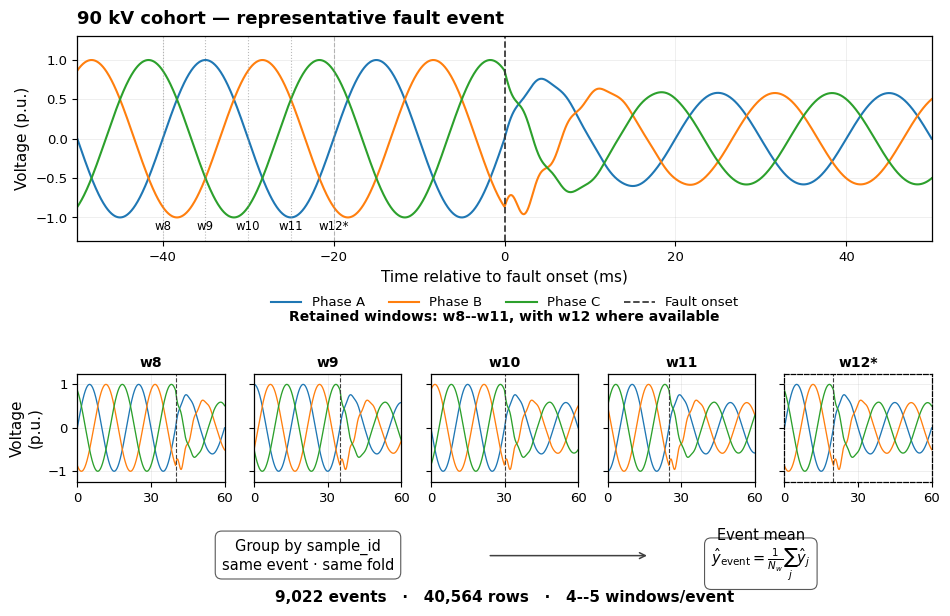

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/lmedoc/figures/ch03/ch03_cohort_construction_90kv.svg


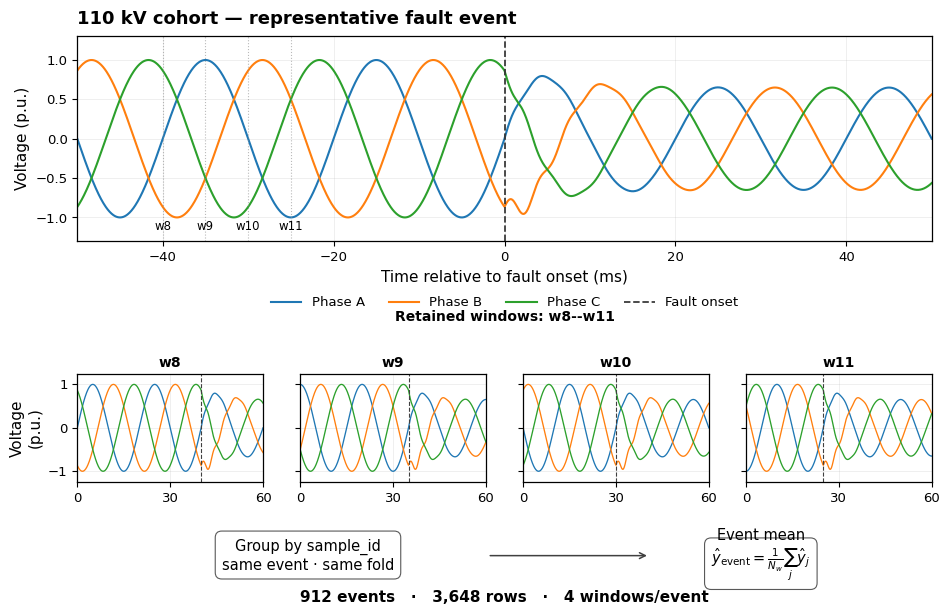

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/lmedoc/figures/ch03/ch03_cohort_construction_110kv.svg

Generated files:
/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/lmedoc/figures/ch03/ch03_cohort_construction_90kv.svg
/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/lmedoc/figures/ch03/ch03_cohort_construction_110kv.svg


In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# =============================================================================
# Output paths
# =============================================================================

PROJECT_ROOT = Path(
    globals().get(
        "THESIS_DIR",
        "/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS",
    )
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "lmedoc"
    / "figures"
    / "ch03"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_90KV = (
    OUTPUT_DIR
    / "ch03_cohort_construction_90kv.svg"
)

OUTPUT_110KV = (
    OUTPUT_DIR
    / "ch03_cohort_construction_110kv.svg"
)


# =============================================================================
# Academic plotting style
# =============================================================================

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10.5,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9.5,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "axes.linewidth": 0.9,
        "grid.linewidth": 0.55,
        "grid.alpha": 0.25,
        "svg.fonttype": "none",
    }
)


# =============================================================================
# Representative three-phase waveform
# =============================================================================

def generate_three_phase_waveform(
    time_ms: np.ndarray,
    *,
    post_fault_amplitude: float,
    transient_amplitude: float,
) -> np.ndarray:
    """Generate a representative three-phase fault waveform."""

    time_seconds = time_ms / 1000.0
    angular_frequency = 2.0 * np.pi * 50.0

    phase_offsets = [
        0.0,
        -2.0 * np.pi / 3.0,
        2.0 * np.pi / 3.0,
    ]

    waveform = np.stack(
        [
            np.sin(
                angular_frequency * time_seconds
                + phase_offset
            )
            for phase_offset in phase_offsets
        ]
    )

    post_fault_time = np.maximum(
        time_ms,
        0.0,
    )

    amplitude_envelope = np.where(
        time_ms < 0.0,
        1.0,
        post_fault_amplitude
        + (
            1.0
            - post_fault_amplitude
        )
        * np.exp(
            -post_fault_time / 5.0
        ),
    )

    waveform = (
        waveform
        * amplitude_envelope[np.newaxis, :]
    )

    transient = np.where(
        time_ms >= 0.0,
        transient_amplitude
        * np.exp(
            -post_fault_time / 5.0
        )
        * np.sin(
            2.0
            * np.pi
            * 300.0
            * time_seconds
        ),
        0.0,
    )

    waveform[0] += 0.25 * transient
    waveform[1] += transient
    waveform[2] -= 0.50 * transient

    return waveform


# =============================================================================
# Figure generator
# =============================================================================

def create_cohort_figure(
    *,
    voltage_level: str,
    events: int,
    rows: int,
    window_indices: list[int],
    windows_per_event: str,
    output_path: Path,
    optional_last_window: bool,
    post_fault_amplitude: float,
    transient_amplitude: float,
):
    window_start_times = {
        8: -40.0,
        9: -35.0,
        10: -30.0,
        11: -25.0,
        12: -20.0,
    }

    number_of_windows = len(
        window_indices
    )

    figure = plt.figure(
        figsize=(
            9.6,
            6.4,
        )
    )

    grid = figure.add_gridspec(
        4,
        1,
        height_ratios=[
            2.45,
            0.42,
            1.30,
            0.90,
        ],
        left=0.09,
        right=0.98,
        top=0.96,
        bottom=0.07,
        hspace=0.46,
    )

    # =========================================================================
    # Main waveform
    # =========================================================================

    event_axis = figure.add_subplot(
        grid[0]
    )

    event_time = np.linspace(
        -50.0,
        50.0,
        1800,
    )

    event_waveform = generate_three_phase_waveform(
        event_time,
        post_fault_amplitude=post_fault_amplitude,
        transient_amplitude=transient_amplitude,
    )

    phase_labels = [
        "Phase A",
        "Phase B",
        "Phase C",
    ]

    legend_handles = []

    for phase_index, phase_label in enumerate(
        phase_labels
    ):
        phase_line, = event_axis.plot(
            event_time,
            event_waveform[phase_index],
            linewidth=1.5,
            label=phase_label,
        )

        legend_handles.append(
            phase_line
        )

    fault_line = event_axis.axvline(
        0.0,
        linestyle="--",
        linewidth=1.25,
        color="0.2",
        label="Fault onset",
    )

    legend_handles.append(
        fault_line
    )

    for window_index in window_indices:
        start_time = window_start_times[
            window_index
        ]

        is_optional = (
            optional_last_window
            and window_index
            == window_indices[-1]
        )

        event_axis.axvline(
            start_time,
            linestyle=(
                "--"
                if is_optional
                else ":"
            ),
            linewidth=0.8,
            color="0.55",
            alpha=0.60,
        )

        event_axis.text(
            start_time,
            -1.20,
            (
                f"w{window_index}*"
                if is_optional
                else f"w{window_index}"
            ),
            ha="center",
            va="bottom",
            fontsize=8.5,
        )

    event_axis.set_title(
        f"{voltage_level} cohort — representative fault event",
        loc="left",
        pad=9,
        fontweight="semibold",
    )

    event_axis.set_xlabel(
        "Time relative to fault onset (ms)"
    )

    event_axis.set_ylabel(
        "Voltage (p.u.)"
    )

    event_axis.set_xlim(
        -50,
        50,
    )

    event_axis.set_ylim(
        -1.30,
        1.30,
    )

    event_axis.grid(
        True
    )

    # =========================================================================
    # Dedicated legend and window description row
    # =========================================================================

    information_axis = figure.add_subplot(
        grid[1]
    )

    information_axis.axis(
        "off"
    )

    information_axis.legend(
        handles=legend_handles,
        labels=[
            "Phase A",
            "Phase B",
            "Phase C",
            "Fault onset",
        ],
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            1.15,
        ),
        ncol=4,
        frameon=False,
        handlelength=2.3,
        columnspacing=1.8,
    )

    if optional_last_window:
        window_description = (
            "Retained windows: w8--w11, with w12 where available"
        )

    else:
        window_description = (
            "Retained windows: w8--w11"
        )

    information_axis.text(
        0.5,
        0.02,
        window_description,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="semibold",
    )

    # =========================================================================
    # Individual 60 ms windows
    # =========================================================================

    windows_grid = grid[
        2
    ].subgridspec(
        1,
        number_of_windows,
        wspace=0.20,
    )

    first_window_axis = None

    for position, window_index in enumerate(
        window_indices
    ):
        if first_window_axis is None:
            window_axis = figure.add_subplot(
                windows_grid[position]
            )

            first_window_axis = window_axis

        else:
            window_axis = figure.add_subplot(
                windows_grid[position],
                sharey=first_window_axis,
            )

        window_start = window_start_times[
            window_index
        ]

        relative_time = np.linspace(
            0.0,
            60.0,
            700,
        )

        absolute_time = (
            window_start
            + relative_time
        )

        window_waveform = generate_three_phase_waveform(
            absolute_time,
            post_fault_amplitude=post_fault_amplitude,
            transient_amplitude=transient_amplitude,
        )

        for phase_index in range(3):
            window_axis.plot(
                relative_time,
                window_waveform[phase_index],
                linewidth=0.95,
            )

        fault_position = (
            -window_start
        )

        window_axis.axvline(
            fault_position,
            linestyle="--",
            linewidth=0.8,
            color="0.25",
        )

        is_optional = (
            optional_last_window
            and position
            == number_of_windows - 1
        )

        window_axis.set_title(
            (
                f"w{window_index}*"
                if is_optional
                else f"w{window_index}"
            ),
            fontsize=10,
            fontweight="semibold",
            pad=5,
        )

        window_axis.set_xlim(
            0,
            60,
        )

        window_axis.set_ylim(
            -1.25,
            1.25,
        )

        window_axis.set_xticks(
            [
                0,
                30,
                60,
            ]
        )

        window_axis.grid(
            True
        )

        if position == 0:
            window_axis.set_ylabel(
                "Voltage\n(p.u.)"
            )

        else:
            window_axis.tick_params(
                axis="y",
                labelleft=False,
            )

        if is_optional:
            for spine in window_axis.spines.values():
                spine.set_linestyle(
                    "--"
                )

    # =========================================================================
    # Minimal aggregation protocol
    # =========================================================================

    aggregation_axis = figure.add_subplot(
        grid[3]
    )

    aggregation_axis.set_xlim(
        0,
        1,
    )

    aggregation_axis.set_ylim(
        0,
        1,
    )

    aggregation_axis.axis(
        "off"
    )

    aggregation_axis.text(
        0.27,
        0.67,
        "Group by sample_id\nsame event · same fold",
        ha="center",
        va="center",
        fontsize=10.5,
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "white",
            "edgecolor": "0.35",
            "linewidth": 0.8,
        },
    )

    aggregation_axis.annotate(
        "",
        xy=(
            0.67,
            0.67,
        ),
        xytext=(
            0.48,
            0.67,
        ),
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.1,
            "color": "0.25",
        },
    )

    aggregation_axis.text(
        0.80,
        0.67,
        (
            "Event mean\n"
            r"$\hat{y}_{\mathrm{event}}"
            r"=\frac{1}{N_w}"
            r"\sum_j\hat{y}_j$"
        ),
        ha="center",
        va="center",
        fontsize=10.5,
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "white",
            "edgecolor": "0.35",
            "linewidth": 0.8,
        },
    )

    aggregation_axis.text(
        0.5,
        0.12,
        (
            f"{events:,} events"
            f"   ·   {rows:,} rows"
            f"   ·   {windows_per_event}"
        ),
        ha="center",
        va="center",
        fontsize=11,
        fontweight="semibold",
    )

    figure.savefig(
        output_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.04,
    )

    plt.show()
    plt.close(
        figure
    )

    print(
        f"Saved: {output_path}"
    )


# =============================================================================
# Generate 90 kV figure
# =============================================================================

create_cohort_figure(
    voltage_level="90 kV",
    events=9022,
    rows=40564,
    window_indices=[
        8,
        9,
        10,
        11,
        12,
    ],
    windows_per_event="4--5 windows/event",
    output_path=OUTPUT_90KV,
    optional_last_window=True,
    post_fault_amplitude=0.58,
    transient_amplitude=0.22,
)


# =============================================================================
# Generate 110 kV figure
# =============================================================================

create_cohort_figure(
    voltage_level="110 kV",
    events=912,
    rows=3648,
    window_indices=[
        8,
        9,
        10,
        11,
    ],
    windows_per_event="4 windows/event",
    output_path=OUTPUT_110KV,
    optional_last_window=False,
    post_fault_amplitude=0.65,
    transient_amplitude=0.17,
)


print()
print("Generated files:")
print(OUTPUT_90KV)
print(OUTPUT_110KV)